In [ ]:
import numpy as np ,matplotlib.pyplot as plt
from sklearn.datasets import make_blobs


x, y_true = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.2,
    random_state=42
)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

x_tr, x_te , y_tr, y_te =train_test_split(
    x, y_true, test_size=0.2, random_state=42
)

clf = LogisticRegression().fit(x_tr, y_tr)
print(f'Supervised accuracy : {clf.score(x_te, y_te):.2%}')

Supervised accuracy : 100.00%


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

cluster_labels = kmeans.fit_predict(x)
print(f'cluster assignments (first 10):',cluster_labels[:10])

cluster assignments (first 10): [1 1 0 2 1 2 0 2 0 0]


In [ ]:
def manual_kmeans(x, k, max_iter=10 , seed=42):
  rng = np.random.default_rng(seed)
  centres = x[rng.choice(len(x),k,replace=False)] # Corrected indentation and variable name
  for  iteration in range(max_iter):
    dists = np.linalg.norm(x[:, np.newaxis] - centres , axis=2)
    labels= np.argmin(dists, axis=1)

    new_centres = np.array([x[labels == k_].mean(axis=0) for k_ in range(k)]) # Corrected axis=0
    print(f'Iter {iteration+1}: centre moved  by {np.linalg.norm(new_centres-centres):.4f}')
    if np.allclose(centres , new_centres): print('-> converged!'); break
    centres = new_centres
  return labels , centres
x ,_= make_blobs(n_samples=200 , centers=3 , random_state=42) # Corrected centers=3
labels,centres= manual_kmeans(x, k=3)

Iter 1: centre moved  by 6.2785
Iter 2: centre moved  by 3.6678
Iter 3: centre moved  by 0.0000
-> converged!


In [ ]:
# ■■ Part 1: Manual K-Means ■■
def manual_kmeans(X, k=3, max_iter=10, seed=42):
  rng = np.random.default_rng(seed)
# Step 1: random initial centres
  centres = X[rng.choice(len(X), k, replace=False)]
  for iteration in range(max_iter):
# Step 2: Assign each point to nearest centre
    dists = np.linalg.norm(X[:, np.newaxis] - centres, axis=2) # (n, k)
    labels = np.argmin(dists, axis=1) # (n,)
# Step 3: Move centres to mean of their cluster
    new_centres = np.array([X[labels == k_].mean(axis=0) for k_ in range(k)])
    print(f'Iter {iteration+1}: centre moved by {np.linalg.norm(new_centres-centres):.4f}')
    if np.allclose(centres, new_centres): print(' → Converged!'); break
    centres = new_centres
  return labels, centres
X, _ = make_blobs(n_samples=200, centers=3, random_state=42)
labels, centres = manual_kmeans(X, k=3)

Iter 1: centre moved by 6.2785
Iter 2: centre moved by 3.6678
Iter 3: centre moved by 0.0000
 → Converged!


In [ ]:
# ■■ Elbow Method + Silhouette Score ■■
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt, numpy as np

In [ ]:
X,_= make_blobs(
    n_samples=400,
    centers=4,
    cluster_std=1.5,
    random_state=42)

In [ ]:
#transforming large data to [-1,1]
X = StandardScaler().fit_transform(X)

inertias, silhouettes, k_range = [], [], range(2, 11)
for k in k_range:
  km = KMeans(n_clusters=k, n_init=10, random_state=42)
  print(k)
  km.fit(X)
  inertias.append(km.inertia_)
  sil = silhouette_score(X, km.labels_) # -1 to +1, higher = better
silhouettes.append(sil)
print(f'K={k:2d} Inertia={km.inertia_:8.2f} Silhouette={sil:.4f}')

2
3
4
5
6
7
8
9
10
K=10 Inertia=   24.51 Silhouette=0.3534


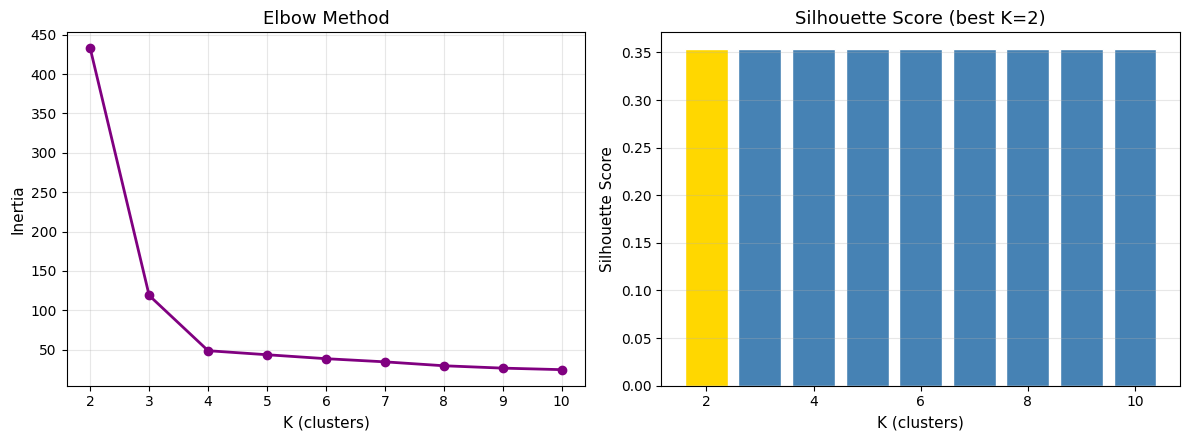


Elbow suggests: look around K=3-5
Silhouette says: best K = 2 (score=0.3534)


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
# Elbow plot
ax1.plot(k_range, inertias, 'o-', color='purple', lw=2)
ax1.set_xlabel('K (clusters)', fontsize=11); ax1.set_ylabel('Inertia', fontsize=11)
ax1.set_title('Elbow Method', fontsize=13); ax1.grid(alpha=0.3)


# Silhouette plot
best_k = k_range[silhouettes.index(max(silhouettes))]
bars = ax2.bar(k_range, silhouettes, color=['gold' if k==best_k else 'steelblue'
for k in k_range], edgecolor='white')
ax2.set_xlabel('K (clusters)', fontsize=11); ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title(f'Silhouette Score (best K={best_k})', fontsize=13); ax2.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()
print(f'\nElbow suggests: look around K=3-5')
print(f'Silhouette says: best K = {best_k} (score={max(silhouettes):.4f})')

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns


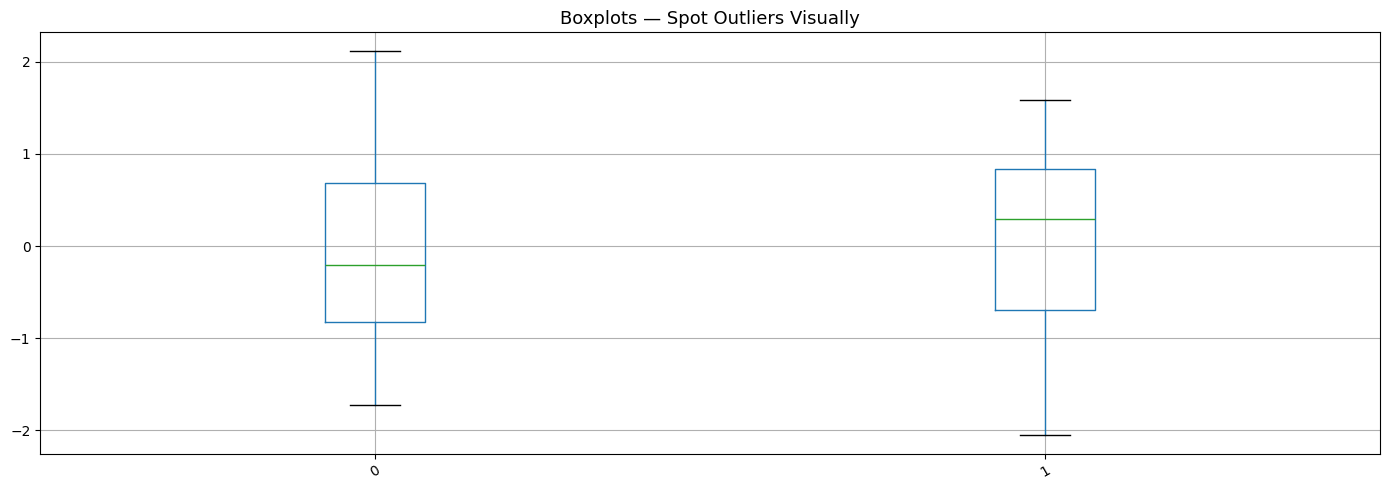

In [ ]:
df = pd.DataFrame(X)
df['Cluster'] = km.labels_

plt.figure(figsize=(14, 5))
df.drop('Cluster', axis=1).boxplot()
plt.title('Boxplots — Spot Outliers Visually', fontsize=13)
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

In [ ]:
def find_outliers(df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  outliers = df[(df[column] < lower) | (df[column] > upper)]
  return outliers, lower, upper
print(f'{'Column':25s} {'Outliers':>8} {'Lower':>8} {'Upper':>8}')
print('-' * 58)
for col in df.select_dtypes(include='number').columns:
  out, lo, hi = find_outliers(df, col)
  if len(out) > 0:
    print(f'{col:25} {len(out):>8} {lo:>8.1f} {hi:>8.1f}')
  else:
    print(f'{col:25} {len(out):>8} {lo:>8} {hi:>8}')


Column                    Outliers    Lower    Upper
----------------------------------------------------------
                        0        0 -3.0924209381600543 2.9485954569780475
                        1        0 -2.9788513300071275 3.1245356567306235
Cluster                          0     -5.5     14.5


In [ ]:
# ■■ Training Error vs Test Error Gap ■■
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt, numpy as np


In [ ]:
X, y = make_classification(
    n_samples=500,
    n_features=10,
    random_state=42)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42)

train_errs, test_errs = [], []

depths = range(1, 25)

for d in depths:

  tree = DecisionTreeClassifier(
      max_depth=d,
      random_state=42)


  tree.fit(X_train, y_train)

  train_errs.append(1 - accuracy_score(y_train, tree.predict(X_train)))
  test_errs.append(1 - accuracy_score(y_test, tree.predict(X_test)))

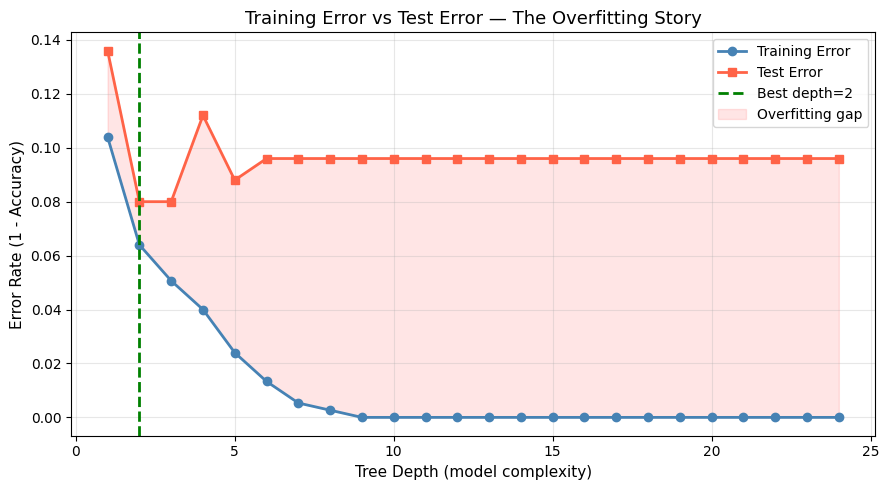

In [ ]:
best = depths[test_errs.index(min(test_errs))]


plt.figure(figsize=(9, 5))
plt.plot(depths, train_errs, 'o-', lw=2, color='steelblue', label='Training Error')
plt.plot(depths, test_errs, 's-', lw=2, color='tomato', label='Test Error')
plt.axvline(x=best, color='green', lw=2, linestyle='--', label=f'Best depth={best}')
plt.fill_between(depths, train_errs, test_errs, alpha=0.1, color='red', label='Overfitting gap')
plt.xlabel('Tree Depth (model complexity)', fontsize=11)
plt.ylabel('Error Rate (1 - Accuracy)', fontsize=11)
plt.title('Training Error vs Test Error — The Overfitting Story', fontsize=13)
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


In [ ]:
# ■■ Cross-Validation: One-liner + StratifiedKFold + Pipeline ■■
from sklearn.datasets import make_classification
from sklearn.model_selection import (cross_val_score, KFold,
StratifiedKFold, cross_validate)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

In [ ]:
X, y = make_classification(n_samples=600, n_features=10, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f'5-Fold CV Scores: {scores.round(3)}')
print(f'Mean: {scores.mean():.3f} Std: {scores.std():.3f}')
print(f'Reliable range: {scores.mean()-2*scores.std():.3f} – scores.mean()+2*score')

5-Fold CV Scores: [0.858 0.933 0.908 0.9   0.942]
Mean: 0.908 Std: 0.029
Reliable range: 0.850 – scores.mean()+2*score


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
strat_scores = cross_val_score(model, X, y, cv=skf, scoring='f1_macro')
print(f'\nStratified 5-Fold F1: {strat_scores.mean():.3f} ± {strat_scores.std():.3f}')


Stratified 5-Fold F1: 0.908 ± 0.027


In [ ]:
# ■■ Method 3: cross_validate — get multiple metrics at once ■■
results = cross_validate(model, X, y, cv=5,
scoring=['accuracy','f1_macro','roc_auc'],
    return_train_score=True)
print('\ncross_validate results:')
for metric in ['accuracy','f1_macro','roc_auc']:
  train_k = f'train_{metric}'
  test_k = f'test_{metric}'
  print(f' {metric:12s}: train={results[train_k].mean():.3f} test={results[test_k].mean():.3f}')


cross_validate results:
 accuracy    : train=1.000 test=0.908
 f1_macro    : train=1.000 test=0.908
 roc_auc     : train=1.000 test=0.970


In [ ]:
# ■■ Method 4: Pipeline + CV (scale inside CV — no data leakage!) ■■
pipe = Pipeline([
('scaler', StandardScaler()), # Scale inside each fold
('model', LogisticRegression(max_iter=1000))
])
pipe_scores = cross_val_score(pipe, X, y, cv=5, scoring='accuracy')
print(f'\nPipeline CV (no leakage): {pipe_scores.mean():.3f} ± {pipe_scores.std():.3f}')


Pipeline CV (no leakage): 0.915 ± 0.030


In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd, numpy as np, matplotlib.pyplot as plt
X, y = make_classification(n_samples=800, n_features=15, random_state=42)

In [ ]:
# ■■ Define models (wrapped in Pipeline to include scaling) ■■
models = {
'Logistic Regression' : Pipeline([('sc',StandardScaler()),('m',LogisticRegression(max_iter=1000))]),
'Decision Tree' : DecisionTreeClassifier(max_depth=5, random_state=42),
'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42),
'KNN (k=5)' : Pipeline([('sc',StandardScaler()),('m',KNeighborsClassifier(n_neighbors=5))])
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():


    cv_res = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=['accuracy', 'f1_macro', 'roc_auc'],
        return_train_score=False
    )



    results.append({
        'Model': name,
        'Accuracy': cv_res['test_accuracy'].mean(),
        'F1 Score': cv_res['test_f1_macro'].mean(),
        'AUC-ROC': cv_res['test_roc_auc'].mean(),
        'CV Std': cv_res['test_accuracy'].std(),

    })

    print(
        f'{name:22s}: '
        f'Acc={results[-1]["Accuracy"]:.3f} '
        f'F1={results[-1]["F1 Score"]:.3f} '
        f'AUC={results[-1]["AUC-ROC"]:.3f} '

    )

Logistic Regression   : Acc=0.930 F1=0.930 AUC=0.975 
Decision Tree         : Acc=0.925 F1=0.925 AUC=0.948 
Random Forest         : Acc=0.936 F1=0.936 AUC=0.977 
KNN (k=5)             : Acc=0.886 F1=0.886 AUC=0.949 


In [ ]:
# ■■ Build the leaderboard ■■
df_res = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
df_res[['Accuracy','F1 Score','AUC-ROC','CV Std']] = df_res[['Accuracy','F1 Score','AUC-ROC','CV Std']].round(4)
print('\n' + '='*70)
print('MODEL LEADERBOARD')
print('='*70)
print(df_res.to_string(index=False))


MODEL LEADERBOARD
              Model  Accuracy  F1 Score  AUC-ROC  CV Std
      Random Forest    0.9362    0.9362   0.9775  0.0310
Logistic Regression    0.9300    0.9300   0.9752  0.0222
      Decision Tree    0.9250    0.9249   0.9481  0.0265
          KNN (k=5)    0.8863    0.8860   0.9487  0.0242
